# Base Line CNN(ConvNeXt-Tiny)

In [ ]:
import torchvision

In [ ]:
# 1. Install Dependencies
!pip install timm --quiet
!pip install seaborn --quiet


# 2. Imports and Device
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [ ]:
# 3. Dataset Preparation (CIFAR-100)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
test_dataset  = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

100%|██████████| 169M/169M [00:06<00:00, 24.7MB/s]


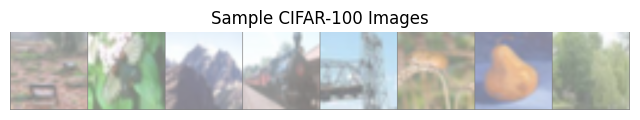

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to show images
def imshow(img, title=""):
    img = img / 2 + 0.5  # unnormalize if you normalize later
    npimg = img.numpy()
    plt.figure(figsize=(8, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis("off")
    plt.show()

# Get a batch of images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show the first 8 images from batch
imshow(torchvision.utils.make_grid(images[:8]), title="Sample CIFAR-100 Images")

In [ ]:
classes = train_dataset.classes

print("Labels:")
for i in range(8):
    print(f"{i+1}. {classes[labels[i]]}")

Labels:
1. television
2. butterfly
3. mountain
4. train
5. bridge
6. mouse
7. pear
8. willow_tree


In [ ]:
# 4. Baseline Model: ConvNeXt-Tiny
baseline_model = timm.create_model("convnext_tiny", pretrained=True, num_classes=100)
baseline_model = baseline_model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [ ]:
# 5. Training + Evaluation Utils
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0

    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            preds = model(imgs)
            loss = F.cross_entropy(preds, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            _, predicted = torch.max(preds.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = F.cross_entropy(preds, labels)
            total_loss += loss.item()
    return total_loss / len(loader)

In [ ]:
# 6. Training Loop with History Tracking
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()

epochs = 10  # small for testing
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(epochs):
    train_loss = train_one_epoch(baseline_model, train_loader, optimizer, scaler)
    train_acc = evaluate(baseline_model, train_loader)
    val_loss = evaluate_loss(baseline_model, test_loader)
    val_acc = evaluate(baseline_model, test_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

/tmp/ipython-input-320701744.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/1563 [00:00<?, ?it/s]/tmp/ipython-input-2622064911.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 1563/1563 [04:34<00:00,  5.69it/s]


Epoch 1 | Train Loss: 1.3452 | Train Acc: 85.51% | Val Loss: 0.6945 | Val Acc: 79.34%


100%|██████████| 1563/1563 [04:07<00:00,  6.31it/s]


Epoch 2 | Train Loss: 0.4499 | Train Acc: 91.77% | Val Loss: 0.6133 | Val Acc: 82.28%


100%|██████████| 1563/1563 [04:07<00:00,  6.31it/s]


...

Epoch 8 | Train Loss: 0.1066 | Train Acc: 98.13% | Val Loss: 0.6733 | Val Acc: 83.37%


100%|██████████| 1563/1563 [04:06<00:00,  6.34it/s]


Epoch 9 | Train Loss: 0.0921 | Train Acc: 97.43% | Val Loss: 0.7961 | Val Acc: 82.08%


100%|██████████| 1563/1563 [04:06<00:00,  6.34it/s]


Epoch 10 | Train Loss: 0.0875 | Train Acc: 97.91% | Val Loss: 0.7060 | Val Acc: 83.03%


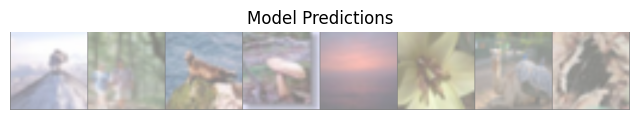


Predicted Labels:
1. road
2. forest
3. seal
4. mushroom
5. sea
6. orchid
7. camel
8. butterfly


In [ ]:
baseline_model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = baseline_model(images)
    _, preds = torch.max(outputs, 1)

# Move images back to CPU for visualization
imshow(torchvision.utils.make_grid(images[:8].cpu()), title="Model Predictions")

print("\nPredicted Labels:")
for i in range(8):
    print(f"{i+1}. {classes[preds[i].item()]}")


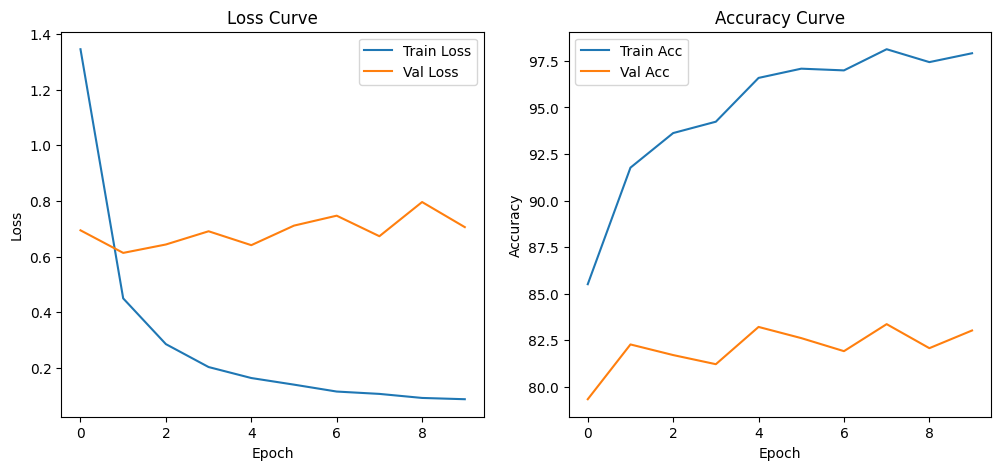

In [ ]:
# 7. Plot Loss & Accuracy Curves
def plot_training(history):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

plot_training(history)

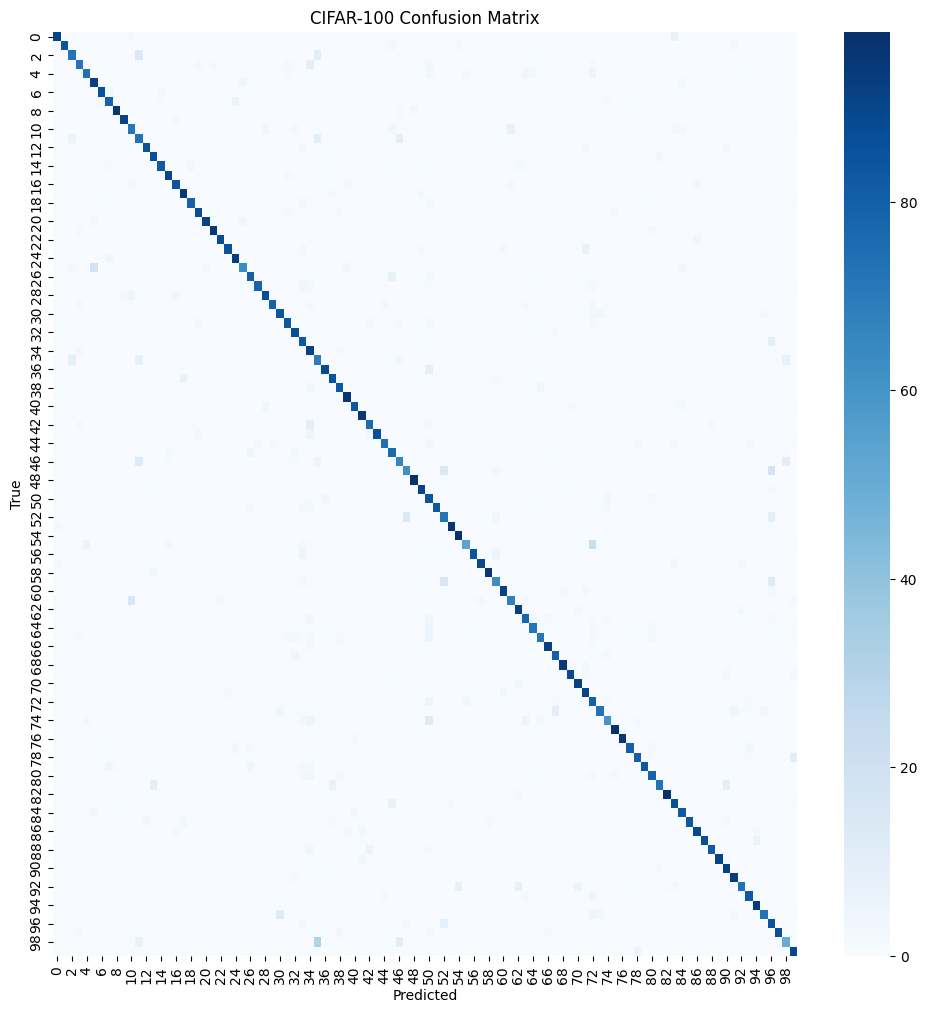

In [ ]:
# 8. Confusion Matrix on Test Set
baseline_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = baseline_model(imgs)
        _, predicted = torch.max(preds.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12,12))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title("CIFAR-100 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

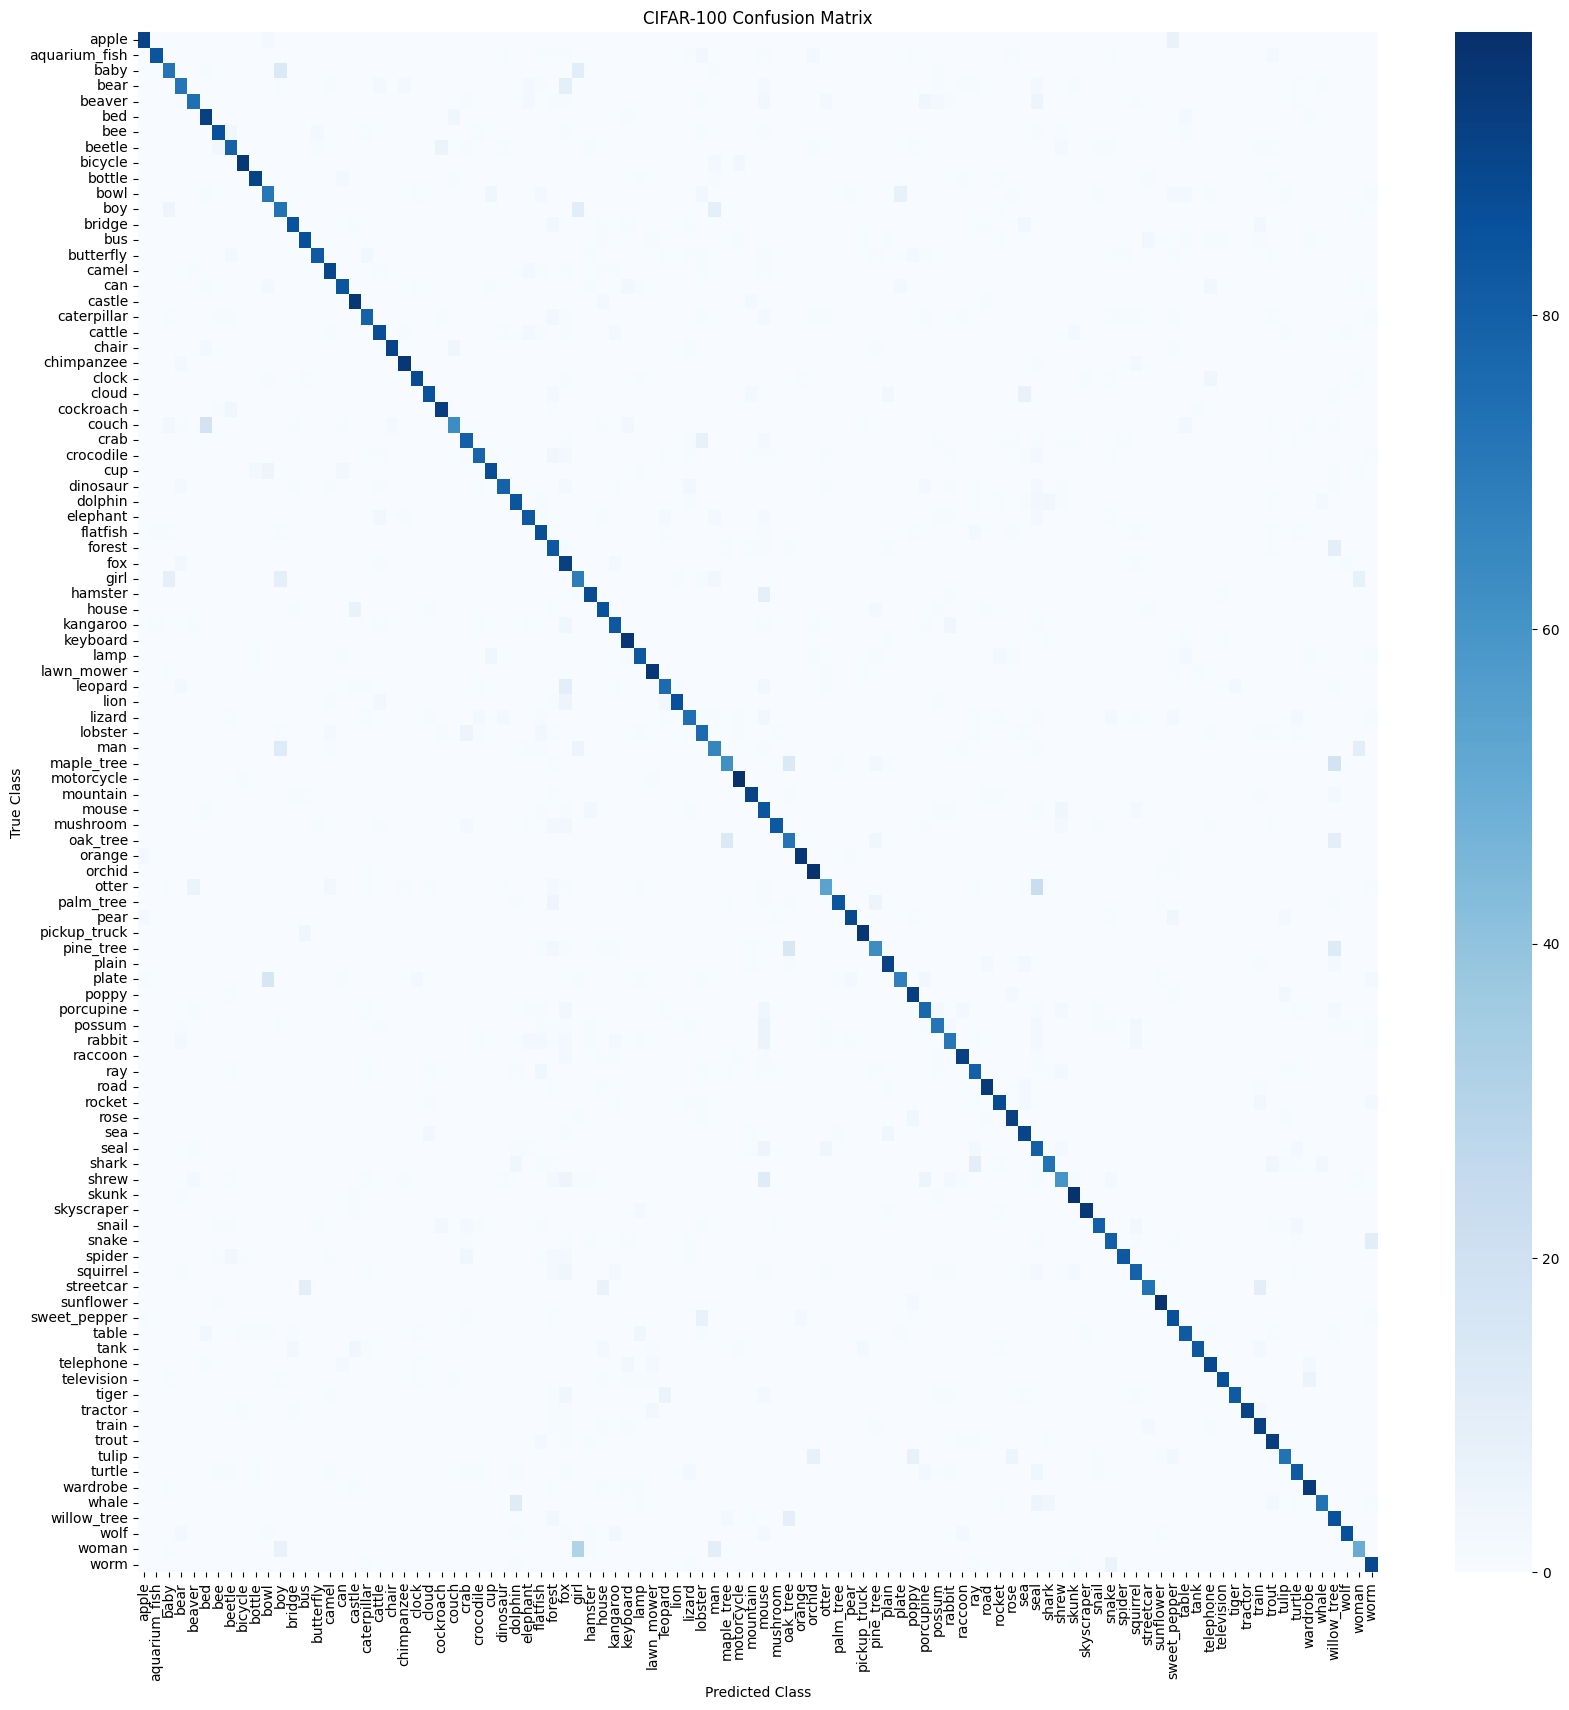

In [ ]:
# 8. Confusion Matrix with Class Names
cifar100_classes = train_dataset.classes  # list of 100 class names

baseline_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = baseline_model(imgs)
        _, predicted = torch.max(preds.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 20))  # bigger figure for 100 classes
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=cifar100_classes,
            yticklabels=cifar100_classes)
plt.title("CIFAR-100 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=90)  # rotate x-axis labels for readability
plt.yticks(rotation=0)
plt.show()


# Base Line VIT (deit_small_distilled_patch16_224)

Using device: cuda


100%|██████████| 169M/169M [00:03<00:00, 47.6MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/89.8M [00:00<?, ?B/s]

ViT feature dim: 384
Global features shape: torch.Size([1, 384])


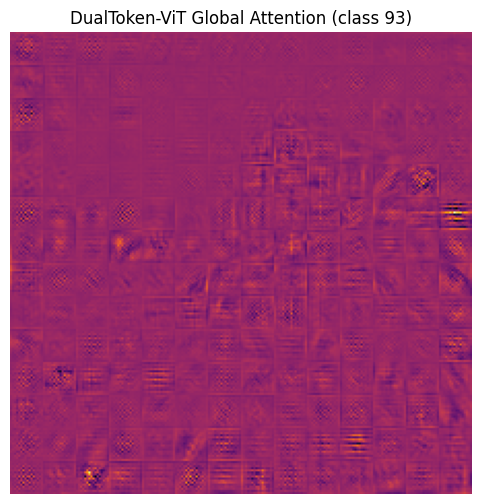

array([[0.43526402, 0.42846835, 0.43989533, ..., 0.42568415, 0.4231884 ,
        0.433014  ],
       [0.4214432 , 0.4015705 , 0.4184744 , ..., 0.4112379 , 0.41188163,
        0.41689107],
       [0.4190572 , 0.4274412 , 0.40714592, ..., 0.41442755, 0.4170063 ,
        0.4205866 ],
       ...,
       [0.4439997 , 0.4119623 , 0.45753428, ..., 0.45627123, 0.44746003,
        0.40723014],
       [0.43029588, 0.4082953 , 0.39780343, ..., 0.44555768, 0.42997253,
        0.41414478],
       [0.42874244, 0.4156103 , 0.42088607, ..., 0.51530343, 0.48522982,
        0.44686273]], dtype=float32)

In [ ]:
# 1. Install Dependencies
!pip install timm --quiet
!pip install torch torchvision --quiet
!pip install matplotlib --quiet
!pip install tqdm --quiet

# 2. Imports & Device
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 3. Dataset (CIFAR-100)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
test_dataset  = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

classes = train_dataset.classes

# 4. DualToken-ViT Setup
VIT_NAME = "deit_small_distilled_patch16_224"

# Classifier-ready ViT
vit_classifier = timm.create_model(VIT_NAME, pretrained=True, num_classes=100).to(device)

# Feature extractor ViT (global context)
vit_feat = timm.create_model(VIT_NAME, pretrained=True, num_classes=0).to(device)
vit_feat.eval()

print("ViT feature dim:", vit_feat.num_features)

# 5. Training Utilities
scaler = torch.amp.GradScaler()
device_type = "cuda" if torch.cuda.is_available() else "cpu"

def train_one_epoch_vit(model, loader, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    pbar = tqdm(loader, desc="vit-train", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type=device_type):
            outputs = model(imgs)
            loss = F.cross_entropy(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += float(loss.item())
        pbar.set_postfix(train_loss=running_loss / (pbar.n + 1e-12))
    return running_loss / len(loader)

@torch.no_grad()
def evaluate_vit(model, loader, device):
    model.eval()
    total, correct = 0, 0
    total_loss = 0.0
    pbar = tqdm(loader, desc="vit-eval", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.amp.autocast(device_type=device_type):
            outputs = model(imgs)
            loss = F.cross_entropy(outputs, labels, reduction="sum")
            preds = outputs.argmax(dim=1)
        total_loss += float(loss.item())
        correct += int((preds == labels).sum().item())
        total += labels.size(0)
    avg_loss = total_loss / total
    acc = 100.0 * correct / total
    return acc, avg_loss

# 6. Feature Extraction (Global Context)
def extract_vit_features(model, img_tensor):
    """
    Extract global context features from DualToken-ViT.
    Handles CLS + distillation token.
    Returns: feature vector of shape (B, feature_dim)
    """
    model.eval()
    img_tensor = img_tensor.to(device)
    with torch.no_grad():
        features = model(img_tensor)  # (B, feature_dim)
    return features

# 7. Attention Visualization
def vit_gradcam(model, img_tensor, target_class=None, upsample_to=(224,224)):
    model.eval()
    img_tensor = img_tensor.to(device)
    img_tensor.requires_grad_()

    outputs = model(img_tensor)
    if target_class is None:
        target_class = outputs.argmax(dim=1).item()

    model.zero_grad()
    loss = outputs[0, target_class]
    loss.backward()

    if hasattr(model, 'patch_embed'):
        features = model.patch_embed(img_tensor)
    else:
        features = img_tensor

    if features.ndim == 4:
        grad = img_tensor.grad.data
        weights = grad.mean(dim=(2,3), keepdim=True)
        cam = (features * weights).sum(dim=1, keepdim=True)
    else:
        cam = img_tensor.grad.data.sum(dim=1, keepdim=True)

    cam = cam.squeeze().detach().cpu()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = F.interpolate(cam.unsqueeze(0).unsqueeze(0), size=upsample_to, mode='bilinear').squeeze().numpy()

    plt.figure(figsize=(6,6))
    plt.imshow(cam, cmap='inferno')
    plt.title(f"DualToken-ViT Global Attention (class {target_class})")
    plt.axis('off')
    plt.show()

    return cam

# 8. Example Usage
imgs, labels = next(iter(test_loader))
one_image = imgs[0:1]  # single image

# Extract global features
global_feat = extract_vit_features(vit_feat, one_image)
print("Global features shape:", global_feat.shape)

# Visualize attention map
vit_gradcam(vit_classifier, one_image)


Epoch 1 | TrainLoss:1.1172 | ValLoss:0.6817 | ValAcc:79.96%


Epoch 2 | TrainLoss:0.4462 | ValLoss:0.6748 | ValAcc:80.29%


Epoch 3 | TrainLoss:0.2872 | ValLoss:0.6010 | ValAcc:82.49%


Epoch 4 | TrainLoss:0.2041 | ValLoss:0.6114 | ValAcc:82.69%


Epoch 5 | TrainLoss:0.1548 | ValLoss:0.6470 | ValAcc:82.56%


Epoch 6 | TrainLoss:0.1227 | ValLoss:0.6425 | ValAcc:83.39%


Epoch 7 | TrainLoss:0.1064 | ValLoss:0.7139 | ValAcc:81.52%


Epoch 8 | TrainLoss:0.0958 | ValLoss:0.7078 | ValAcc:82.66%


Epoch 9 | TrainLoss:0.0856 | ValLoss:0.7447 | ValAcc:81.97%


Epoch 10 | TrainLoss:0.0791 | ValLoss:0.7475 | ValAcc:82.50%


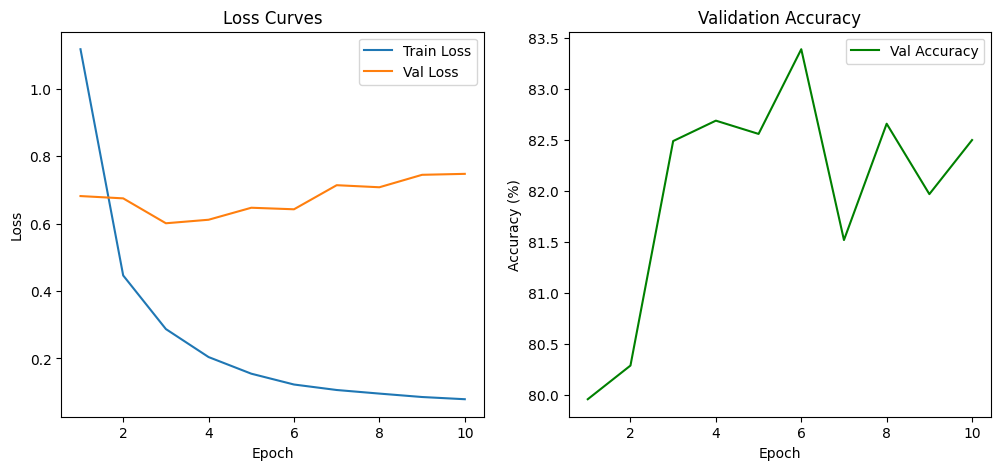

<Figure size 1500x1500 with 0 Axes>

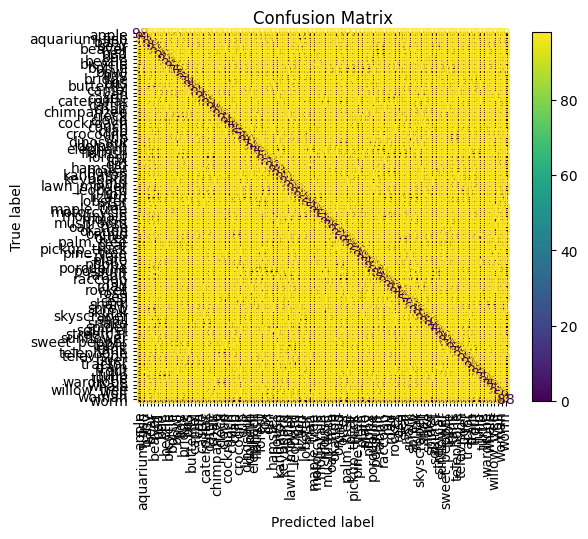

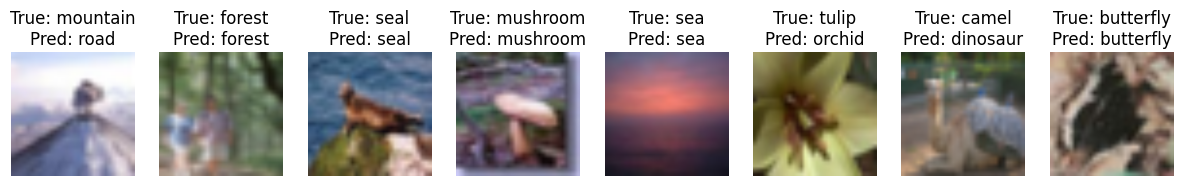

In [ ]:
# 9. Extended Training to Track Metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Storage for metrics
train_losses, val_losses = [], []
val_accuracies = []

optimizer = torch.optim.Adam(vit_classifier.parameters(), lr=1e-4)
epochs = 10

for epoch in range(epochs):
    # Train
    tloss = train_one_epoch_vit(vit_classifier, train_loader, optimizer, scaler, device)
    # Evaluate
    acc, vloss = evaluate_vit(vit_classifier, test_loader, device)

    # Store metrics
    train_losses.append(tloss)
    val_losses.append(vloss)
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1} | TrainLoss:{tloss:.4f} | ValLoss:{vloss:.4f} | ValAcc:{acc:.2f}%")

# 10. Plot Loss & Accuracy Curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), val_accuracies, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy')
plt.legend()

plt.show()

# 11. Confusion Matrix
vit_classifier.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = vit_classifier(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
plt.figure(figsize=(15,15))
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()

# 12. Predicted Labels / Sample Visualization
def show_predictions(model, loader, num_samples=8):
    model.eval()
    imgs, labels = next(iter(loader))
    imgs, labels = imgs[:num_samples].to(device), labels[:num_samples].to(device)
    outputs = model(imgs)
    preds = outputs.argmax(dim=1)

    imgs = imgs.cpu().permute(0,2,3,1).numpy()  # CHW -> HWC
    plt.figure(figsize=(15,5))
    for i in range(num_samples):
        plt.subplot(1,num_samples,i+1)
        plt.imshow(imgs[i])
        plt.title(f"True: {classes[labels[i]]}\nPred: {classes[preds[i]]}")
        plt.axis('off')
    plt.show()

show_predictions(vit_classifier, test_loader)
